# 📌 Introduction

In this notebook, dimension reduction with Principal Component Analysis (PCA) will be performed on the breast cancer dataset consisting of 30 features. The original dataset and the reduced dimension dataset will be classified using Random Forest and k-Nearest Neighbors (kNN) algorithms. The results will be compared for a different number of components by looking at the variance ratios on the PCA.

#### Content:
    
1. [Load and Check Data](#1)
    * [Correlation Matrix](#2)
    
1. [Classifiers](#3)
    * [Standardization](#4)
    * [Import Libraries](#5)
    * [Classification using Random Forest with Original 30 Features](#6)
    * [Classification using kNN with Original 30 Features](#7)
   
1. [Principal Component Analysis (PCA)](#8)
    * [PCA Components - Variance Relationship](#9)
    * [Classification using Random Forest with 2 PC](#10)
    * [Classification using kNN with 2 PC](#11)
    * [Classification using Random Forest with 5 PC](#12)
    * [Classification using kNN with 5 PC](#13)
    * [Classification using Random Forest with 10 PC](#14)
    * [Classification using kNN with 10 PC](#15)


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/breast-cancer-wisconsin-data/data.csv


<a id='1'></a><br>
# Load and Check Data

In [2]:
data = pd.read_csv("/kaggle/input/breast-cancer-wisconsin-data/data.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
# Drop unnecessary columns
data.drop(["Unnamed: 32","id"],axis=1,inplace=True)
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# Categorical data convert to numeric data
data["diagnosis"] = [1 if item == "M" else 0  for item in data["diagnosis"]]

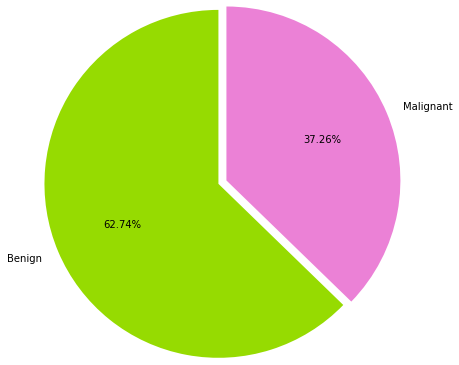

In [6]:
colors = ['#96db01','#eb81d6']
plt.pie(data.diagnosis.value_counts(),startangle=90,explode=[0.05,0.05],autopct='%0.2f%%',
        labels=['Benign', 'Malignant'], colors= colors,radius=2)
plt.show()

### 

<a id='2'></a><br>
### Correlation Matrix

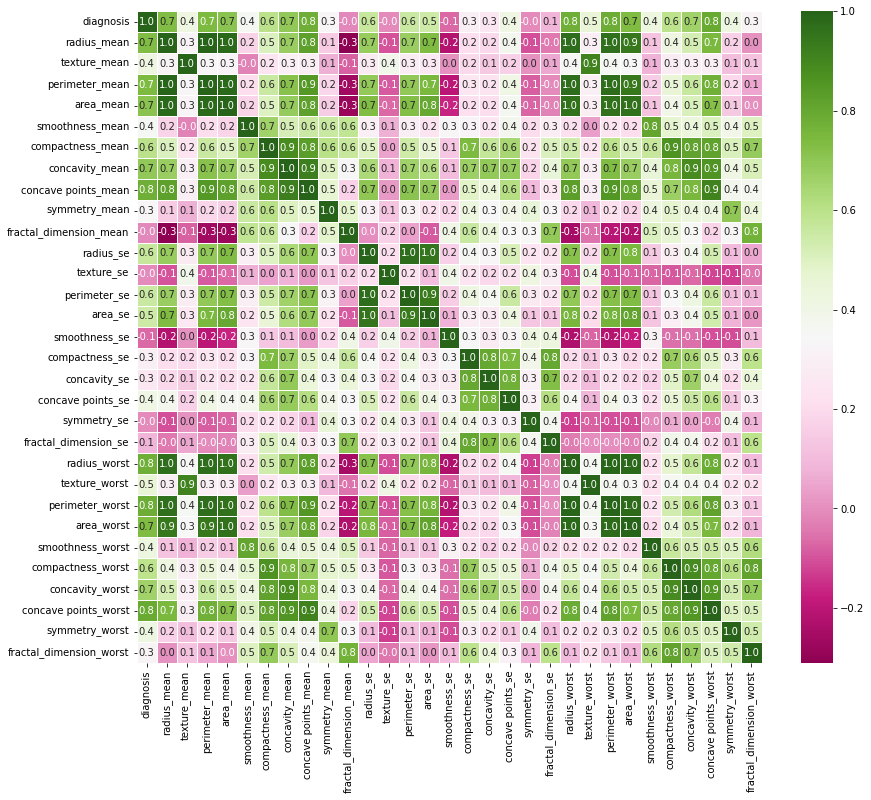

In [7]:
import seaborn as sns
f,ax = plt.subplots(figsize=(14,12))
sns.heatmap(data.corr(), cmap="PiYG", annot=True, linewidths=0.5, fmt= '.1f',ax=ax)
plt.show()

In [8]:
# Prepare Data for classification
x = data.drop(['diagnosis'], axis = 1)
y = data.loc[:,"diagnosis"].values

In [9]:
# Columns name
col = x.columns

<a id='3'></a><br>
# Classifiers

<a id='4'></a><br>
### Standardization

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x)
x = scaler.transform(x)

<a id='5'></a><br>
### Import Libraries

In [11]:
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score,cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

**To validate machine learning models, 10-Fold Cross-Validation is repeated 10 times using Repeated K-Fold Cross-Validation.**

Repeated k-Fold Cross-Validation: Repeated k-fold cross-validation provides a way to improve the estimated performance of a machine learning model. This involves simply repeating the cross-validation procedure multiple times and reporting the mean result across all folds from all runs.

<a id='6'></a><br>
### Classification using Random Forest with Original 30 Features 

In [12]:
r_forest = RandomForestClassifier(max_depth=100, random_state=0)
cv = RepeatedKFold(n_splits=10, n_repeats=10, random_state=1)
scores = cross_val_score(r_forest, x, y, scoring='accuracy', cv=cv)
rf_score = np.mean(scores)

print('Accuracy : %.3f' % (rf_score))

Accuracy : 0.962


In [13]:
y_pred = cross_val_predict(r_forest, x, y, cv=10)
cf_matrix = confusion_matrix(y, y_pred)

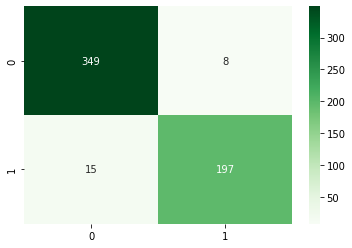

In [14]:
sns.heatmap(cf_matrix, annot=True, fmt='.0f', cmap="Greens")
plt.show()

<a id='7'></a><br>
### Classification using kNN with Original 30 Features

In [15]:
 for i in range(1,16):
    neigh = KNeighborsClassifier(n_neighbors=i)
    cv = RepeatedKFold(n_splits=10, n_repeats=10, random_state=1)
    scores = cross_val_score(neigh, x, y, scoring='accuracy', cv=cv)
    print('k=%d : %.3f' % (i, (np.mean(scores))))

k=1 : 0.953
k=2 : 0.958
k=3 : 0.967
k=4 : 0.967
k=5 : 0.969
k=6 : 0.965
k=7 : 0.966
k=8 : 0.965
k=9 : 0.970
k=10 : 0.966
k=11 : 0.968
k=12 : 0.964
k=13 : 0.964
k=14 : 0.961
k=15 : 0.962


#### **The best k parameter is 9**

In [16]:
neigh = KNeighborsClassifier(n_neighbors=9)
cv = RepeatedKFold(n_splits=10, n_repeats=10, random_state=1)
scores = cross_val_score(neigh, x, y, scoring='accuracy', cv=cv)
knn_score = np.mean(scores)

print('Accuracy : %.3f' % (knn_score))

Accuracy : 0.970


In [17]:
y_pred = cross_val_predict(neigh, x, y, cv=10)
cf_matrix = confusion_matrix(y, y_pred)

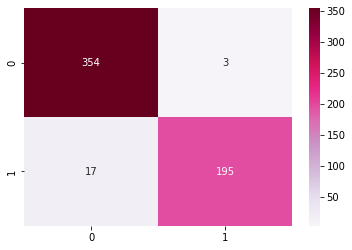

In [18]:
sns.heatmap(cf_matrix, annot=True, fmt='.0f', cmap="PuRd")
plt.show()

* When the classification results for rf and knn are examined, it is seen that the accuracy values are quite close.
* When confusion matrix is examined, it is seen that Random Forest is more successful for class 1, while kNN is more successful for class 0.

<a id='8'></a><br>
# Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a multivariate technique for analyzing quantitative data. PCA turns a set of related variables into a set of unrelated variables. The purpose of PCA is to reduce dimensionality, noise and extract important information (features) from large amounts of data. PCA is one of the most widely used tools in exploratory data analysis and machine learning for predictive models.

In [19]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(x)
pca_ = pca.transform(x)

<a id='9'></a><br>
### PCA Components - Variance Relationship

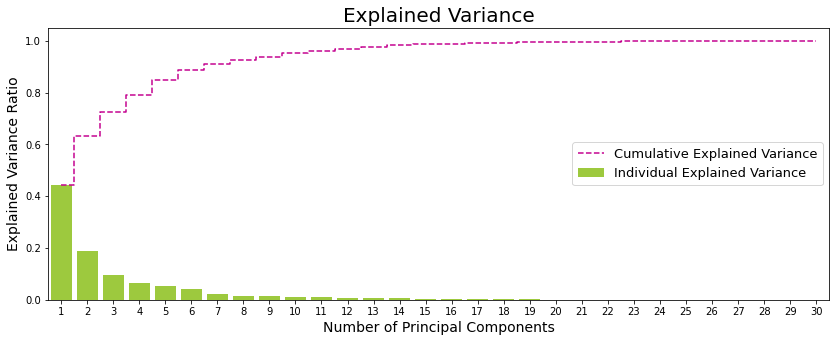

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))
plt.plot(range(x.shape[1]), pca.explained_variance_ratio_.cumsum(), linestyle='--', drawstyle='steps-mid', color='#c4008f',
         label='Cumulative Explained Variance')
sns.barplot(np.arange(1,x.shape[1]+1), pca.explained_variance_ratio_, alpha=0.85, color='#96db01',
            label='Individual Explained Variance')

plt.ylabel('Explained Variance Ratio', fontsize = 14)
plt.xlabel('Number of Principal Components', fontsize = 14)
ax.set_title('Explained Variance', fontsize = 20)
plt.legend(loc='center right', fontsize = 13);

* According to the graph, the first two principal components explain more than half of the variance, the five components explain approximately %85 of the variance, and the ten components explain approximately %95 of the variance.

<a id='10'></a><br>
### Classification using Random Forest with 2 PC

In [21]:
pca = PCA(2)
pca.fit(x)
pca_ = pca.transform(x)

In [22]:
r_forest = RandomForestClassifier(max_depth=100, random_state=0)
cv = RepeatedKFold(n_splits=10, n_repeats=10, random_state=1)
scores = cross_val_score(r_forest, pca_, y, scoring='accuracy', cv=cv)
r_score = np.mean(scores)

print('Accuracy : %.3f' % (r_score))

Accuracy : 0.937


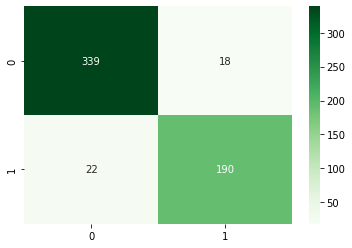

In [23]:
y_pred = cross_val_predict(r_forest, pca_, y, cv=10)
cf_matrix = confusion_matrix(y, y_pred)
sns.heatmap(cf_matrix, annot=True, fmt='.0f', cmap="Greens")
plt.show()

<a id='11'></a><br>
### Classification using kNN with 2 PC

In [24]:
neigh = KNeighborsClassifier(n_neighbors=9)
cv = RepeatedKFold(n_splits=10, n_repeats=10, random_state=1)
scores = cross_val_score(neigh, pca_, y, scoring='accuracy', cv=cv)
knn_score = np.mean(scores)

print('Accuracy : %.3f' % (knn_score))

Accuracy : 0.944


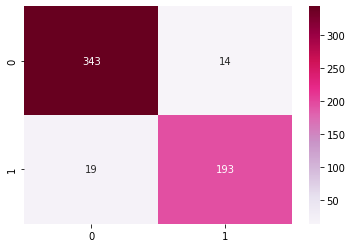

In [25]:
y_pred = cross_val_predict(neigh, pca_, y, cv=10)
cf_matrix = confusion_matrix(y, y_pred)
sns.heatmap(cf_matrix, annot=True, fmt='.0f', cmap="PuRd")
plt.show()

* More successful results were obtained with kNN when the first 2 PC were used for classification. Although the results obtained with 2 components are lower than the results obtained for 30 features, they are successful for only 2 dimensions.

<a id='12'></a><br>
### Classification using Random Forest with 5 PC

In [26]:
pca = PCA(5)
pca.fit(x)
pca_ = pca.transform(x)

In [27]:
r_forest = RandomForestClassifier(max_depth=100, random_state=0)
cv = RepeatedKFold(n_splits=10, n_repeats=10, random_state=1)
scores = cross_val_score(r_forest, pca_, y, scoring='accuracy', cv=cv)
r_score = np.mean(scores)

print('Accuracy : %.3f' % (r_score))

Accuracy : 0.954


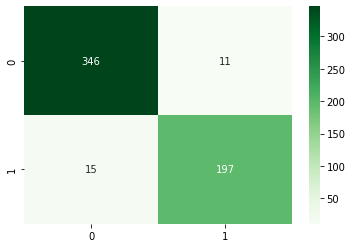

In [28]:
y_pred = cross_val_predict(r_forest, pca_, y, cv=10)
cf_matrix = confusion_matrix(y, y_pred)
sns.heatmap(cf_matrix, annot=True, fmt='.0f', cmap="Greens")
plt.show()

<a id='13'></a><br>
### Classification using kNN with 5 PC

In [29]:
neigh = KNeighborsClassifier(n_neighbors=9)
cv = RepeatedKFold(n_splits=10, n_repeats=10, random_state=1)
scores = cross_val_score(neigh, pca_, y, scoring='accuracy', cv=cv)
knn_score = np.mean(scores)

print('Accuracy : %.3f' % (knn_score))

Accuracy : 0.960


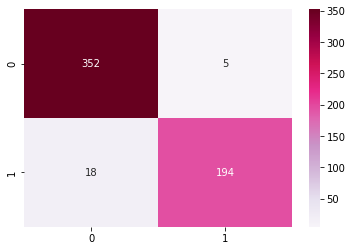

In [30]:
y_pred = cross_val_predict(neigh, pca_, y, cv=10)
cf_matrix = confusion_matrix(y, y_pred)
sns.heatmap(cf_matrix, annot=True, fmt='.0f', cmap="PuRd")
plt.show()

* Results are higher than 2 components, as 5 principal components explain approximately %85 of the variance. Slightly higher results were obtained with kNN classifier than Random Forest. It can be seen that the confusion matrices obtained with 5 PCs are quite similar to the confusion matrices obtained with 30 features.

<a id='14'></a><br>
### Classification using Random Forest with 10 PC

In [31]:
pca = PCA(10)
pca.fit(x)
pca_ = pca.transform(x)

In [32]:
r_forest = RandomForestClassifier(max_depth=100, random_state=0)
cv = RepeatedKFold(n_splits=10, n_repeats=10, random_state=1)
scores = cross_val_score(r_forest, pca_, y, scoring='accuracy', cv=cv)
r_score = np.mean(scores)

print('Accuracy : %.3f' % (r_score))

Accuracy : 0.950


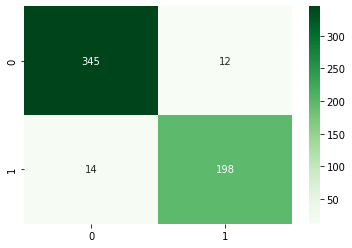

In [33]:
y_pred = cross_val_predict(r_forest, pca_, y, cv=10)
cf_matrix = confusion_matrix(y, y_pred)
sns.heatmap(cf_matrix, annot=True, fmt='.0f', cmap="Greens")
plt.show()

<a id='15'></a><br>
### Classification using kNN with 10 PC

In [34]:
neigh = KNeighborsClassifier(n_neighbors=9)
cv = RepeatedKFold(n_splits=10, n_repeats=10, random_state=1)
scores = cross_val_score(neigh, pca_, y, scoring='accuracy', cv=cv)
knn_score = np.mean(scores)

print('Accuracy : %.3f' % (knn_score))

Accuracy : 0.966


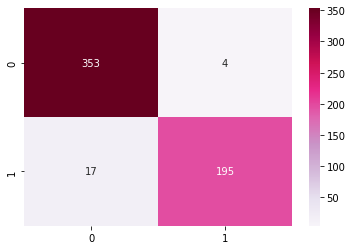

In [35]:
y_pred = cross_val_predict(neigh, pca_, y, cv=10)
cf_matrix = confusion_matrix(y, y_pred)
sns.heatmap(cf_matrix, annot=True, fmt='.0f', cmap="PuRd")
plt.show()

* Variance should be explained in the range of %95-99 with PCA optimal number of principal components. For this dataset, the 10 principal components explain approximately %95 of the variance. kNN classifier achieved better results than Random Forest. Although more successful results are obtained with 10 components than with 2 and 5 components, the results are very close to the results obtained with 5 components.